In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# paths

res = "gridsearch_results1"
par = "gridsearch_segments1"

results_csv = f"/Users/chrismader/Python/SLDS/DRO/{res}.csv"
segments_parquet = f"/Users/chrismader/Python/SLDS/DRO/{par}.parquet"
out = f"/Users/chrismader/Python/SLDS/temp_parquet/"

In [4]:
def list_configs_from_parquet(path: str) -> list[str]:
    """
    Return a sorted list of unique config values in a segments parquet.
    Expects a 'config' column.
    """
    df = pd.read_parquet(path, columns=["config"])
    if "config" not in df.columns:
        raise ValueError("missing column: 'config'")
    return sorted(df["config"].dropna().astype(str).unique().tolist())

configs = list_configs_from_parquet(segments_parquet)
configs

['[y,h]', '[y]', 'factor2_ff3', 'factor2_ff3mom', 'fund1', 'fund1_vix']

In [5]:
import pandas as pd, re
import pyarrow.parquet as pq

path = segments_parquet  # your path

# 1) Pandas columns
df = pd.read_parquet(path)
cols = list(df.columns)
print("COLUMNS:", sorted(cols))

# 2) Check expected names
targets = ["n_regimes","K","k","nStates","n_states","dim_latent","latent_dim","D","dim"]
present = [c for c in targets if c in cols]
print("TARGET COLUMNS FOUND:", present)

# 3) Fuzzy search for likely fields
hits = [c for c in cols if re.search(r"(regime|state|latent|dim)", c, re.I)]
print("FUZZY HITS:", hits)

# 4) Arrow-level schema (authoritative)
pf = pq.ParquetFile(path)
print(pf.schema_arrow)  # full field list with types

# 5) Quick peek if any target exists
for c in present:
    print(c, df[c].dropna().unique()[:10])


COLUMNS: ['config', 'date', 'security', 't', 'z']
TARGET COLUMNS FOUND: []
FUZZY HITS: []
security: string
config: string
date: timestamp[ns]
t: int32
z: int16
-- schema metadata --
pandas: '{"index_columns": [], "column_indexes": [], "columns": [{"name":' + 618


In [43]:
import pandas as pd
import numpy as np
import ast

def _first_present(df, cols):
    for c in cols:
        if c in df.columns:
            return c
    return None

def _parse_dim(v):
    if pd.isna(v):
        return np.nan
    if isinstance(v, (int, float)):
        return int(v) if np.isfinite(v) else np.nan
    s = str(v).strip()
    try:
        lit = ast.literal_eval(s)
        if isinstance(lit, (list, tuple)):
            # keep the vector as a tuple
            return tuple(int(x) for x in lit)
        if isinstance(lit, (int, float)):
            return int(lit)
    except Exception:
        pass
    # fallback to numeric if possible
    try:
        x = pd.to_numeric(s, errors="coerce")
        return int(x) if np.isfinite(x) else np.nan
    except Exception:
        return np.nan

def list_config_tuples(segments_parquet: str):
    seg = pd.read_parquet(segments_parquet)
    seg["config"] = seg["config"].astype(str).str.strip()

    k_col = _first_present(seg, ["n_regimes","K","k","nStates","n_states"])
    d_col = _first_present(seg, ["dim_latent","latent_dim","D","dim"])

    if k_col is None:
        raise ValueError("No n_regimes/K column found in parquet.")
    if d_col is None:
        raise ValueError("No dim_latent column found in parquet.")

    tmp = seg[["config", k_col, d_col]].drop_duplicates().copy()
    tmp["n_regimes"] = pd.to_numeric(tmp[k_col], errors="coerce").astype("Int64")
    tmp["dim_latent"] = tmp[d_col].apply(_parse_dim)

    # unique tuples
    tuples = []
    for _, r in tmp.iterrows():
        tuples.append((r["config"], (None if pd.isna(r["n_regimes"]) else int(r["n_regimes"])), r["dim_latent"]))

    # sort stable: by config, then n_regimes, then dim_latent as string
    tuples = sorted(tuples, key=lambda t: (t[0], -1 if t[1] is None else t[1], str(t[2])))

    return tuples

# usage
tuples = list_config_tuples(segments_parquet)
for t in tuples:
    print(t)


ValueError: No n_regimes/K column found in parquet.

In [41]:
def regimes_wide_from_parquet(path: str, config: str, value_col: str = "z") -> pd.DataFrame:
    """
    Input parquet schema: columns ['security','config','date','t','z'].
    Returns wide DataFrame indexed by datetime, columns=securities, values=z.
    """
    df = pd.read_parquet(path)

    # basic checks
    need = {"security", "config", "date", "t", value_col}
    missing = need - set(df.columns)
    if missing:
        raise ValueError(f"missing columns: {sorted(missing)}")

    # filter to the chosen config
    df = df.loc[df["config"] == config].copy()
    if df.empty:
        return pd.DataFrame()

    # normalize types
    df["date"] = pd.to_datetime(df["date"], utc=False, errors="coerce")
    df = df.dropna(subset=["date"])
    if "t" in df:
        # keep the last observation per (security,date) after sorting by t
        df = df.sort_values(["security", "date", "t"]).drop_duplicates(
            subset=["security", "date"], keep="last"
        )

    # pivot to wide
    wide = (
        df.pivot(index="date", columns="security", values=value_col)
          .sort_index()
    )

    # use nullable integer if possible
    try:
        wide = wide.astype("Int64")
    except Exception:
        pass  # leave as float with NaNs if casting not possible

    wide.index.name = None
    return wide


In [42]:
# save each config as wide format csv
for config in configs:
    df = regimes_wide_from_parquet(path=segments_parquet, config=config)
    df.to_csv(f"{out}_{res}_{config}.csv")

In [6]:
def regime_share_by_security(df: pd.DataFrame, states=range(7), decimals: int = 0) -> pd.DataFrame:
    # Long form without stack
    long = (
        df.astype("Int64")
          .melt(ignore_index=False, var_name="security", value_name="z")
          .dropna(subset=["z"])
    )
    long["z"] = long["z"].astype(int)

    counts = (
        long.groupby(["security", "z"])
            .size()
            .unstack(fill_value=0)
            .reindex(columns=list(states), fill_value=0)
    )

    totals = counts.sum(axis=1).replace(0, np.nan)
    pct = counts.div(totals, axis=0).multiply(100).fillna(0.0).round(decimals)

    # Force each row to 100 by adjusting the max cell
    row_sum = pct.sum(axis=1)
    diff = (100.0 - row_sum).round(decimals).to_numpy()
    if pct.shape[1] > 0:
        jmax = np.argmax(pct.to_numpy(), axis=1)
        arr = pct.to_numpy()
        for i, j in enumerate(jmax):
            if diff[i] != 0:
                arr[i, j] = round(arr[i, j] + diff[i], decimals)
        pct = pd.DataFrame(arr, index=pct.index, columns=pct.columns)

    pct["Total"] = 100.0
    return pct


In [7]:
wide = regimes_wide_from_parquet(segments_parquet, 'factor2_ff3')
shares = regime_share_by_security(wide)
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 0)
print(shares.to_string())

z            0      1     2     3     4     5    6  Total
security                                                 
AAPL      46.0   22.0   7.0   0.0   9.0  16.0  0.0  100.0
ACN        9.0   12.0  20.0   7.0  15.0  37.0  0.0  100.0
ADBE       5.0    7.0  12.0   0.0  27.0  49.0  0.0  100.0
AMAT       8.0    7.0  38.0   7.0  25.0  15.0  0.0  100.0
AMD        0.0   14.0  61.0  18.0   0.0   7.0  0.0  100.0
AMZN      54.0    0.0   7.0   2.0  29.0   8.0  0.0  100.0
AVGO      22.0    8.0   0.0  18.0  45.0   7.0  0.0  100.0
BKNG      15.0   18.0  43.0  10.0   7.0   7.0  0.0  100.0
COST       3.0    0.0  12.0  22.0  52.0  11.0  0.0  100.0
CRM        6.0   25.0   0.0  15.0   7.0  47.0  0.0  100.0
CSCO      18.0   10.0  10.0   5.0  45.0  12.0  0.0  100.0
DIS       13.0   13.0  22.0  15.0   0.0  37.0  0.0  100.0
GOOGL     22.0   15.0  37.0  18.0   0.0   8.0  0.0  100.0
HD        22.0   47.0   0.0   3.0  13.0  15.0  0.0  100.0
IBM       30.0    8.0   0.0   9.0   8.0  45.0  0.0  100.0
INTU       9.0

In [36]:
import pandas as pd
import numpy as np

def active_matrix_from_parquet_by_regime(
    segments_parquet: str,
    config: str,
    min_lb: int,
    max_lb: int,
) -> pd.DataFrame:
    seg = pd.read_parquet(segments_parquet)
    seg = seg.loc[seg["config"].astype(str).str.strip() == str(config).strip()].copy()
    seg["security"] = seg["security"].astype(str).str.strip()
    seg["date"] = pd.to_datetime(seg["date"], errors="coerce")
    seg = seg.dropna(subset=["date","security"]).sort_values(["security","date"])
    seg = seg.drop_duplicates(subset=["security","date"], keep="last")

    # Wide labels table
    Z = seg.pivot(index="date", columns="security", values="z").sort_index().astype("Int64")
    Z.index = pd.DatetimeIndex(Z.index)

    # Infer observed states from the parquet
    z_vals = pd.unique(Z.values.ravel("K"))
    z_vals = [int(v) for v in z_vals if pd.notna(v)]

    pres = Z.notna()
    counts_same = pd.DataFrame(0, index=Z.index, columns=Z.columns, dtype="int32")

    # Rolling count of days in last max_lb with the SAME label as today
    for z in z_vals:
        mask_z = (Z == z)
        cnt_z = mask_z.rolling(window=int(max_lb), min_periods=1).sum()
        counts_same = counts_same.where(~mask_z, cnt_z)

    active = (pres & (counts_same >= int(min_lb))).astype("int8")
    return active

active_df = active_matrix_from_parquet_by_regime(
    segments_parquet, config="factor2_ff3", min_lb=21, max_lb=1260)

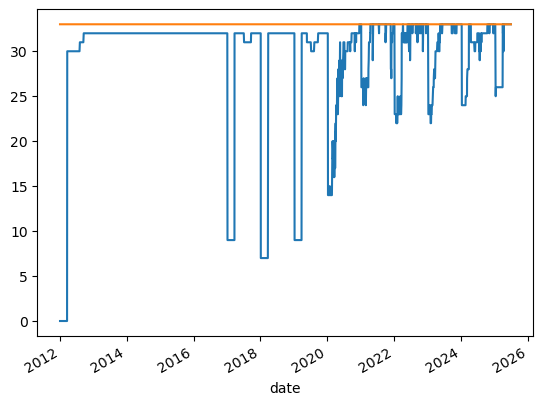

In [37]:
active_df.sum(axis=1).plot()
active_df.count(axis=1).plot()
plt.show()